In [25]:
from brian2 import *

start_scope()

### neuron model parameters ###
C = 200*pF
g_leak = 10*nS
tau = 20*ms
V_rest = -60*mV
reversal_P = 0*mV
reversal_B = -70*mV
reversal_A = -70*mV
V_th = -50*mV
V_reset = -60*mV

### synapse parameters ###
synaptic_delay = 1*ms

tau_syn_P = 2*ms
tau_syn_A = 4*ms
tau_syn_B = 1.5*ms

tau_D = 250*ms
eta_D = 0.18
e_AB = 0.5

# synapric conductance increases and connection probabilities
g_PP = 0.2*nS
p_PP = 0.01

g_PA = 6*nS
p_PA = 0.6

g_PB = 0.7*nS
p_PB = 0.5

g_AP = 0.2*nS
p_AP = 0.01

g_AA = 4*nS
p_AA = 0.6

g_AB = 8*nS
p_AB = 0.2

g_BP = 0.05*nS
p_BP = 0.2

g_BA = 7*nS
p_BA = 0.6

g_BB = 5*nS
p_BB =0.2

# population sizes
N_P = 8200
N_B = 135
N_A = 50

### currents ###
I_BG = 200*pA
I_i = 0*pA
I_ext = I_BG + I_i



### equations ###
eqs = '''
dv/dt = (g_leak*(V_rest - v) - (g_P*(v-reversal_P) + g_A*(v-reversal_A) + g_B*(v-reversal_B)) + I_ext)/C : volt (unless refractory)
dg_P/dt = -g_P/tau_syn_P : siemens
dg_A/dt = -g_A/tau_syn_A : siemens
dg_B/dt = -g_B/tau_syn_B : siemens
de_AB/dt = (1-e_AB)/tau_D : 1
'''

#d - 
### neurons groups ###
group_P = NeuronGroup(N_P, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')
group_A = NeuronGroup(N_A, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')
group_B = NeuronGroup(N_B, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')

### synapses ###
synapse_PP = Synapses(group_P, group_P, on_pre='g_P_post += g_PP')
synapse_PP.connect(p=p_PP)
synapse_PP.delay = synaptic_delay
synapse_PA = Synapses(group_P, group_A, on_pre='g_A_post += g_PA')
synapse_PA.connect(p=p_PA)
synapse_PA.delay = synaptic_delay
synapse_PB = Synapses(group_P, group_B, on_pre='g_B_post += g_PB')
synapse_PB.connect(p=p_PB)
synapse_PB.delay = synaptic_delay

synapse_AA = Synapses(group_A, group_A, on_pre='g_A_post += g_AA')
synapse_AA.connect(p=p_AA)
synapse_AA.delay = synaptic_delay
synapse_AP = Synapses(group_A, group_P, on_pre='g_P_post += g_AP')
synapse_AP.connect(p=p_AP)
synapse_AP.delay = synaptic_delay
synapse_AB = Synapses(group_A, group_B, on_pre='''g_B_post += g_AB*e_AB
                                                e_AB -= e_AB * eta_D
                      ''')
synapse_AB.connect(p=p_AB)
synapse_AB.delay = synaptic_delay
synapse_AB.e_AB_post = e_AB

synapse_BB = Synapses(group_B, group_B, on_pre='g_B_post += g_BB')
synapse_BB.connect(p=p_BB)
synapse_BB.delay = synaptic_delay
synapse_BA = Synapses(group_B, group_A, on_pre='g_A_post += g_BA')
synapse_BA.connect(p=p_BA)
synapse_BA.delay = synaptic_delay
synapse_BP = Synapses(group_B, group_P, on_pre='g_P_post += g_BP')
synapse_BP.connect(p=p_BP)
synapse_BP.delay = synaptic_delay



WARNING    'e_AB' is an internal variable of group 'neurongroup_1', but also exists in the run namespace with the value 0.5. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'e_AB' is an internal variable of group 'neurongroup_2', but also exists in the run namespace with the value 0.5. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'e_AB' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 0.5. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'e_AB' is an internal variable of group 'synapses_5', but also exists in the run namespace with the value 0.5. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


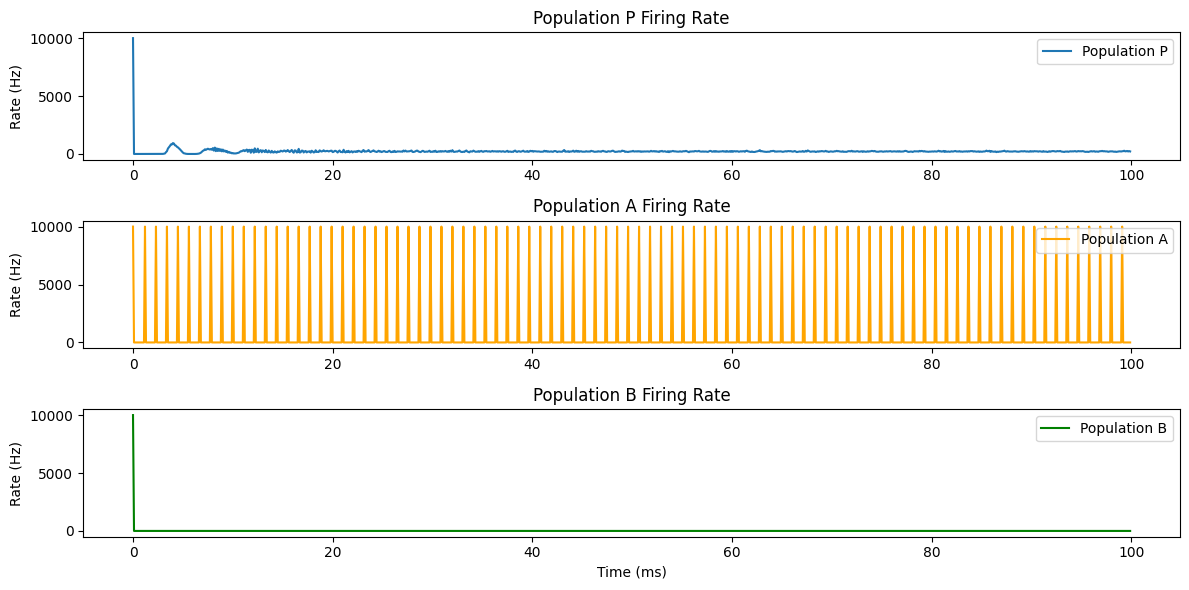

In [26]:
import matplotlib.pyplot as plt
from brian2 import PopulationRateMonitor

# Add PopulationRateMonitors
pop_rate_P = PopulationRateMonitor(group_P)
pop_rate_A = PopulationRateMonitor(group_A)
pop_rate_B = PopulationRateMonitor(group_B)

# Run the simulation
run(100*ms)

# Plot population rates
plt.figure(figsize=(12, 6))

# Population P
plt.subplot(3, 1, 1)
plt.plot(pop_rate_P.t/ms, pop_rate_P.rate/Hz, label='Population P')
plt.ylabel('Rate (Hz)')
plt.title('Population P Firing Rate')
plt.legend()


# Population A
plt.subplot(3, 1, 2)
plt.plot(pop_rate_A.t/ms, pop_rate_A.rate/Hz, label='Population A', color='orange')
plt.ylabel('Rate (Hz)')
plt.title('Population A Firing Rate')
plt.legend()

# Population B
plt.subplot(3, 1, 3)
plt.plot(pop_rate_B.t/ms, pop_rate_B.rate/Hz, label='Population B', color='green')
plt.xlabel('Time (ms)')
plt.ylabel('Rate (Hz)')
plt.title('Population B Firing Rate')
plt.legend()

plt.tight_layout()
plt.show()
